# Classify Italian Brainrot characters

Train a small YOLO classifier on the [Italian Brainrot Images](https://www.kaggle.com/datasets/bubblepw/italian-brainrot-images) dataset, then watch it name a character.

## Set up your computer

### 1. Make a Kaggle account

Go to [kaggle.com](https://www.kaggle.com) and sign up.

### 2. Download your API token

Open [kaggle.com/settings](https://www.kaggle.com/settings). In the API section, click **Create New Token**. Your browser downloads a file named `kaggle.json`. Leave it in your Downloads folder. You will move it in a later step.

### 3. Open a terminal

- **Windows:** press the Windows key, type `PowerShell`, and open it.
- **Mac:** press Command+Space, type `Terminal`, and open it.
- **Linux:** open the Terminal app.

### 4. Install Git

Check whether Git is already installed:

```bash
git --version
```

If that prints a version number, go to the next step.

- **Windows:** install Git from [git-scm.com/download/win](https://git-scm.com/download/win). Keep the default options. Close PowerShell and open it again.
- **Mac:** run `xcode-select --install` and click Install.
- **Linux (Ubuntu):** run `sudo apt install git`.

### 5. Download this project

```bash
git clone https://github.com/Marcuss2106/italian_brainrot_image_classifier.git
cd italian_brainrot_image_classifier
```

Stay in this folder for the rest of the commands.

### 6. Save your Kaggle token

Mac or Linux:

```bash
mkdir -p ~/.kaggle
mv ~/Downloads/kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json
```

Windows PowerShell:

```powershell
mkdir $HOME\.kaggle -Force
Move-Item $HOME\Downloads\kaggle.json $HOME\.kaggle\kaggle.json
```

If the file in Downloads has a slightly different name, use that name in the command.

### 7. Install uv

uv downloads Python for you.

Mac or Linux:

```bash
curl -LsSf https://astral.sh/uv/install.sh | sh
```

Windows PowerShell:

```powershell
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
```

Close the terminal, open a new one, then run:

```bash
cd italian_brainrot_image_classifier
uv --version
```

### 8. Install the libraries

```bash
uv sync
```

The first run takes a few minutes.

### 9. Open this notebook in your browser

```bash
uv run --with notebook jupyter notebook notebooks/01_classify_italian_brainrot.ipynb
```

A browser tab opens. Press **Shift+Enter** to run each cell. Press **Ctrl+C** in the terminal when you are finished.

## Download the images

This uses the `kaggle.json` file from setup.

In [1]:
import os

import kagglehub
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

dataset_path = kagglehub.dataset_download("bubblepw/italian-brainrot-images")
image_folder = os.path.join(dataset_path, "brainrot_dataset")

class_names = [
    "ballerina_cappuccina",
    "bombardino_crocodilo",
    "cappuccino_assassino",
    "tralalero_tralala",
    "tung_tung_sahur",
]


def photos_in(class_name):
    folder = os.path.join(image_folder, class_name)
    photos = []
    for file_name in sorted(os.listdir(folder)):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            photos.append(os.path.join(folder, file_name))
    return photos


for class_name in class_names:
    print(class_name, len(photos_in(class_name)))

/home/marcus-sostak/italian_brainrot_image_classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ballerina_cappuccina 200
bombardino_crocodilo 200
cappuccino_assassino 200
tralalero_tralala 200
tung_tung_sahur 200


## Look at one photo per character

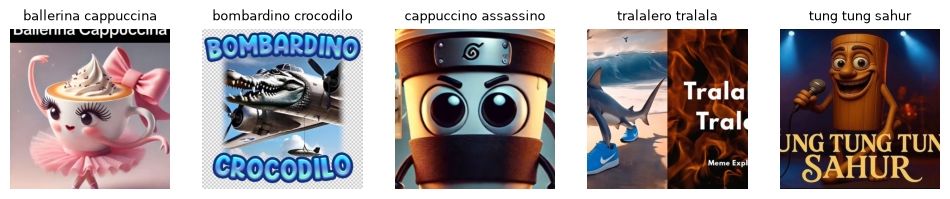

In [2]:
plt.figure(figsize=(12, 3))
for i, class_name in enumerate(class_names):
    photo = photos_in(class_name)[0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(Image.open(photo))
    plt.title(class_name.replace("_", " "), fontsize=9)
    plt.axis("off")
plt.show()

## Train

Wait for the percent at the end. That is the score on photos the model did not train on.

In [3]:
model = YOLO("yolo11n-cls.pt")
metrics = model.train(data=image_folder, epochs=5, imgsz=224, plots=False)
print(f"Got {metrics.top1:.0%} of the held-out photos right")

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU, 7706MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/marcus-sostak/.cache/kagglehub/datasets/bubblepw/italian-brainrot-images/versions/2/brainrot_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

## Pick a photo

Leave `pick` as `"any"`, or type a character name. Run the cell again for a new photo.

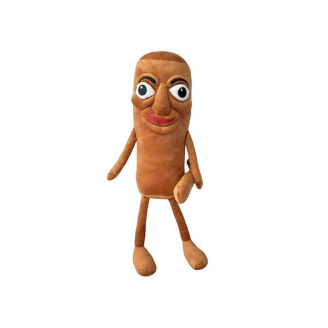

In [4]:
import random

pick = "any"  # or "tralalero_tralala", "tung_tung_sahur", ...

if pick == "any":
    class_name = random.choice(class_names)
else:
    class_name = pick

photo = random.choice(photos_in(class_name))

plt.figure(figsize=(4, 4))
plt.imshow(Image.open(photo))
plt.axis("off")
plt.show()

## See the scores

The tallest bar is the model's answer. The title is the real folder.

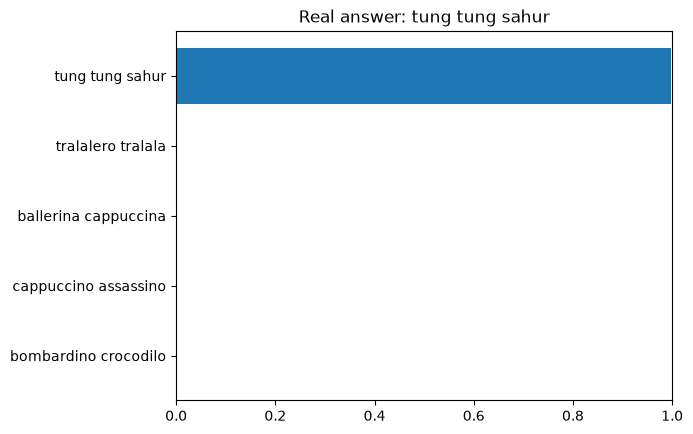

In [5]:
result = model(photo, verbose=False)[0]

labels = []
scores = []
for class_id, confidence in zip(result.probs.top5, result.probs.top5conf):
    labels.append(result.names[class_id].replace("_", " "))
    scores.append(float(confidence))

plt.barh(labels[::-1], scores[::-1])
plt.xlim(0, 1)
plt.title(f"Real answer: {class_name.replace('_', ' ')}")
plt.show()